# 3D Arena Sankeys

In [1]:
import pandas as pd
import plotly.graph_objects as go
import os
import matplotlib.pyplot as plt
! pip install -U kaleido

In [ ]:
# MAKE CHANGES HERE

# Input files used for analysis
filename = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\042025_2mp\combined_matrix_final_total_mp.csv'
filename_groups = r'Z:\Members\Mia-Sanjana-Hadent\Processed Data\042025_2mp\cluster_groups_matlab.csv'

# Output directory for cluster usage change .csv files
output_dir = r'D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs'
os.makedirs(output_dir, exist_ok=True)

# Output directory for graphs. Use the path to .eps, .png will be automatically generated
eps_dir = r"D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps"

# Use any label for mouse
mouse_name = "2mp"  

In [3]:
all_data = pd.read_csv(os.path.join(filename))
grouped_clusters = pd.read_csv(os.path.join(filename_groups))

In [ ]:
custom_colors = [  
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
    "#1e90ff", "#ff1493", "#00ced1", "#ff69b4", "#7cfc00", "#ff6347", "#00ff7f", "#4682b4",
    "#da70d6", "#40e0d0", "#dc143c", "#00bfff", "#ff8c00", "#9932cc", "#8b0000", "#00fa9a",
    "#6495ed", "#ba55d3", "#f0e68c", "#ff00ff", "#00ffff", "#adff2f", "#ffa500", "#87ceeb",
    "#f08080", "#20b2aa", "#f5deb3", "#ffb6c1", "#2e8b57", "#ffdab9", "#b0e0e6", "#cd5c5c",
    "#dda0dd", "#fa8072", "#eee8aa", "#7fffd4", "#b22222", "#8fbc8f", "#ffdead", "#ff7f50",
    "#ffefd5", "#5f9ea0", "#ff69b4", "#bdb76b", "#8a2be2", "#ff1493", "#d2691e", "#bc8f8f",
    "#8b4513", "#00ced1", "#b0c4de", "#ffe4e1", "#2f4f4f", "#696969", "#d2b48c", "#fafad2"
]

week_numbers = sorted(all_data['Week_Number'].dropna().unique())

In [5]:
def create_arena_sankey_and_pies(data, week_number, eps_dir="", mouse_name=""):
    data = data.copy()
    data['Next_Cluster'] = data['Cluster'].shift(-1)
    data['Next_Week_Number'] = data['Week_Number'].shift(-1)
    data = data[data['Week_Number'] == data['Next_Week_Number']]

    transition_counts = data.groupby(['Cluster', 'Next_Cluster']).size().unstack(fill_value=0)
    transition_probabilities = transition_counts.div(transition_counts.sum(axis=1), axis=0)
    all_clusters = sorted(data['Cluster'].dropna().astype(int).unique())
    outgoing_counts = {f"Cluster {i}": 0 for i in all_clusters}
    incoming_counts = {f"Cluster {i}": 0 for i in all_clusters}

    for col in transition_probabilities.columns:
        for row in transition_probabilities.index:
            prob = transition_probabilities.at[row, col]
            if prob > 0:
                src = f"Cluster {int(row)}"
                tgt = f"Cluster {int(col)}"
                if src in outgoing_counts:
                    outgoing_counts[src] += 1
                if tgt in incoming_counts:
                    incoming_counts[tgt] += 1

    print(f"\n--- Incoming and Outgoing Flow Counts for Week {week_number} ---")
    for clust in all_clusters:
        cname = f"Cluster {clust}"
        print(f"{cname}: Incoming = {incoming_counts.get(cname, 0)}, Outgoing = {outgoing_counts.get(cname, 0)}")


    def plot_pie_chart(counts, title, save_path=None):
        labels = list(counts.keys())
        sizes = list(counts.values())
        total = sum(sizes)

        display_labels = [
            label.replace("Cluster ", "") if (value / total * 100) >= 1 else ""
            for label, value in zip(labels, sizes)
        ]

        pie_colors = [custom_colors[int(label.split()[1]) % len(custom_colors)] for label in labels]

        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=display_labels,
            colors=pie_colors,
            startangle=140,
            textprops={'fontsize': 8}
        )
        plt.title(title, pad=10)
        plt.axis('equal')
        
        if save_path is not None:
            eps_dir = os.path.dirname(save_path)
            if eps_dir:
                os.makedirs(eps_dir, exist_ok=True)

            base_filename = os.path.splitext(os.path.basename(save_path))[0]
            eps_path = os.path.join(eps_dir, base_filename + ".eps")
            plt.savefig(eps_path, format="eps", bbox_inches="tight")
            print(f"EPS saved to: {eps_path}")

            parent_dir = os.path.dirname(eps_dir)
            png_dir = os.path.join(parent_dir, "png")
            os.makedirs(png_dir, exist_ok=True)
            png_path = os.path.join(png_dir, base_filename + ".png")
            plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")
            print(f"PNG saved to: {png_path}")
        plt.show()

    incoming_chart_counts = {k: v for k, v in incoming_counts.items() if v > 0}
    outgoing_chart_counts = {k: v for k, v in outgoing_counts.items() if v > 0}

    incoming_path = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_incoming.eps"
    )
    outgoing_path = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_outgoing.eps"
    )

    plot_pie_chart(incoming_chart_counts, f"Incoming Flows - Week {week_number}", save_path=incoming_path)
    plot_pie_chart(outgoing_chart_counts, f"Outgoing Flows - Week {week_number}", save_path=outgoing_path)


--- Incoming and Outgoing Flow Counts for Week 8 ---
Cluster 1: Incoming = 37, Outgoing = 37
Cluster 2: Incoming = 40, Outgoing = 36
Cluster 3: Incoming = 48, Outgoing = 42
Cluster 4: Incoming = 24, Outgoing = 28
Cluster 5: Incoming = 46, Outgoing = 44
Cluster 6: Incoming = 44, Outgoing = 44
Cluster 7: Incoming = 37, Outgoing = 40
Cluster 8: Incoming = 35, Outgoing = 37
Cluster 9: Incoming = 43, Outgoing = 37
Cluster 10: Incoming = 49, Outgoing = 41
Cluster 11: Incoming = 47, Outgoing = 41
Cluster 12: Incoming = 43, Outgoing = 43
Cluster 13: Incoming = 40, Outgoing = 38
Cluster 14: Incoming = 44, Outgoing = 42
Cluster 15: Incoming = 25, Outgoing = 26
Cluster 16: Incoming = 25, Outgoing = 23
Cluster 17: Incoming = 45, Outgoing = 44
Cluster 18: Incoming = 24, Outgoing = 26
Cluster 19: Incoming = 30, Outgoing = 32
Cluster 20: Incoming = 32, Outgoing = 34
Cluster 21: Incoming = 19, Outgoing = 22
Cluster 22: Incoming = 27, Outgoing = 33
Cluster 23: Incoming = 19, Outgoing = 26
Cluster 24: 

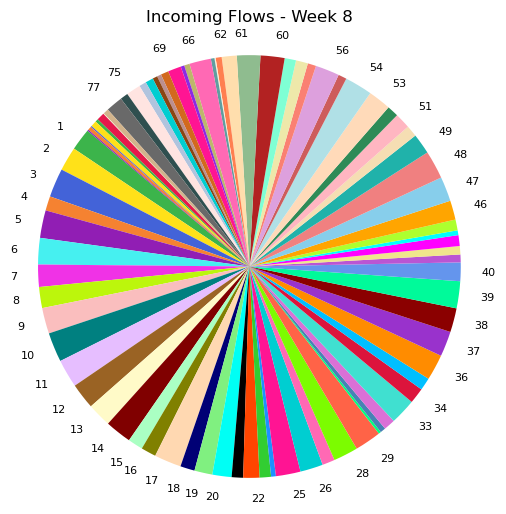

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week8_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week8_outgoing.png


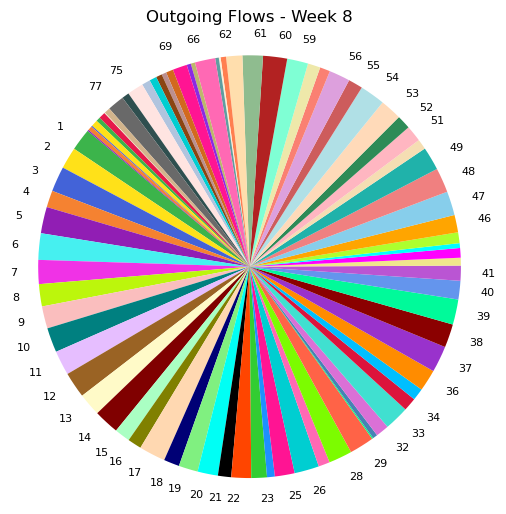


--- Incoming and Outgoing Flow Counts for Week 10 ---
Cluster 1: Incoming = 37, Outgoing = 32
Cluster 2: Incoming = 39, Outgoing = 41
Cluster 3: Incoming = 45, Outgoing = 46
Cluster 4: Incoming = 32, Outgoing = 29
Cluster 5: Incoming = 44, Outgoing = 43
Cluster 6: Incoming = 44, Outgoing = 44
Cluster 7: Incoming = 43, Outgoing = 45
Cluster 8: Incoming = 40, Outgoing = 33
Cluster 9: Incoming = 39, Outgoing = 40
Cluster 10: Incoming = 50, Outgoing = 42
Cluster 11: Incoming = 40, Outgoing = 38
Cluster 12: Incoming = 43, Outgoing = 41
Cluster 13: Incoming = 43, Outgoing = 40
Cluster 14: Incoming = 44, Outgoing = 47
Cluster 15: Incoming = 30, Outgoing = 26
Cluster 16: Incoming = 26, Outgoing = 25
Cluster 17: Incoming = 42, Outgoing = 39
Cluster 18: Incoming = 36, Outgoing = 38
Cluster 19: Incoming = 37, Outgoing = 39
Cluster 20: Incoming = 29, Outgoing = 23
Cluster 21: Incoming = 30, Outgoing = 30
Cluster 22: Incoming = 32, Outgoing = 33
Cluster 23: Incoming = 19, Outgoing = 19
Cluster 24:

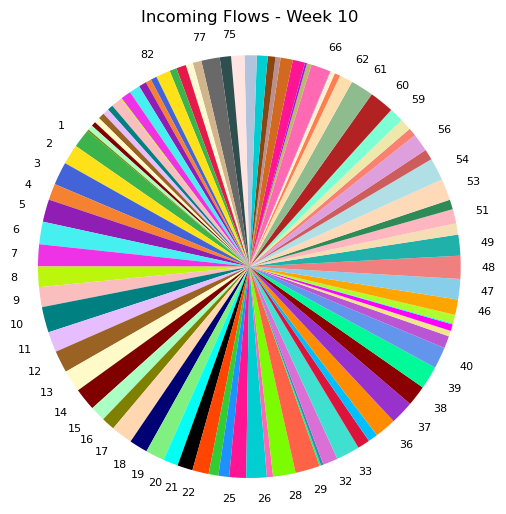

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week10_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week10_outgoing.png


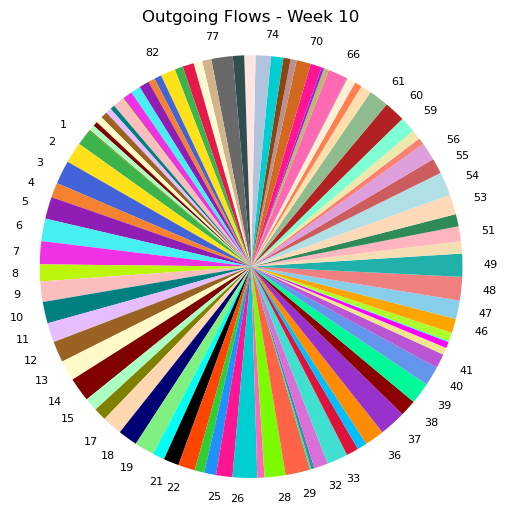


--- Incoming and Outgoing Flow Counts for Week 12 ---
Cluster 1: Incoming = 27, Outgoing = 30
Cluster 2: Incoming = 43, Outgoing = 36
Cluster 3: Incoming = 55, Outgoing = 48
Cluster 4: Incoming = 30, Outgoing = 31
Cluster 5: Incoming = 48, Outgoing = 41
Cluster 6: Incoming = 48, Outgoing = 40
Cluster 7: Incoming = 50, Outgoing = 47
Cluster 8: Incoming = 35, Outgoing = 35
Cluster 9: Incoming = 43, Outgoing = 39
Cluster 10: Incoming = 46, Outgoing = 36
Cluster 11: Incoming = 37, Outgoing = 33
Cluster 12: Incoming = 42, Outgoing = 41
Cluster 13: Incoming = 41, Outgoing = 38
Cluster 14: Incoming = 49, Outgoing = 50
Cluster 15: Incoming = 22, Outgoing = 23
Cluster 16: Incoming = 17, Outgoing = 21
Cluster 17: Incoming = 44, Outgoing = 42
Cluster 18: Incoming = 39, Outgoing = 41
Cluster 19: Incoming = 39, Outgoing = 45
Cluster 20: Incoming = 31, Outgoing = 33
Cluster 21: Incoming = 34, Outgoing = 33
Cluster 22: Incoming = 29, Outgoing = 36
Cluster 23: Incoming = 16, Outgoing = 16
Cluster 24:

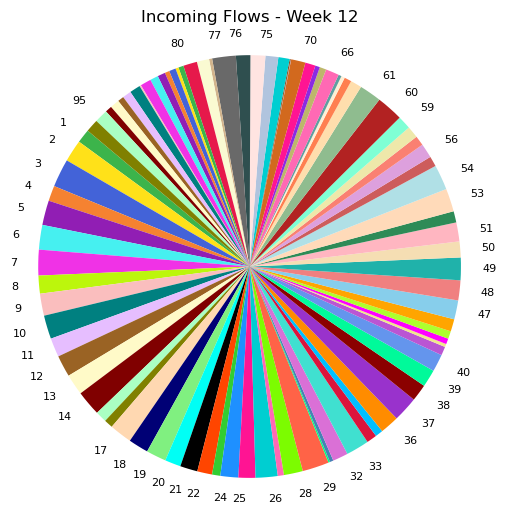

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week12_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week12_outgoing.png


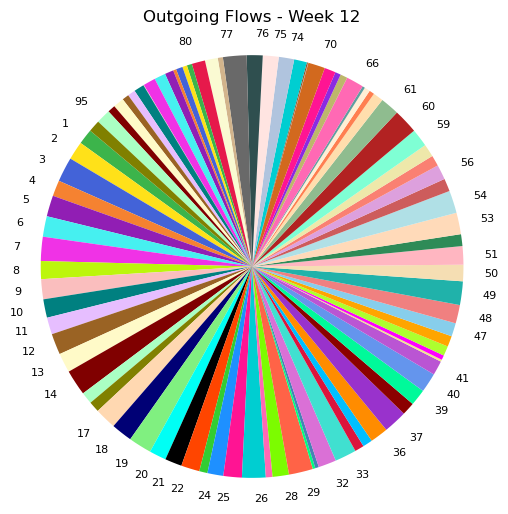


--- Incoming and Outgoing Flow Counts for Week 14 ---
Cluster 1: Incoming = 24, Outgoing = 20
Cluster 2: Incoming = 34, Outgoing = 34
Cluster 3: Incoming = 50, Outgoing = 46
Cluster 4: Incoming = 20, Outgoing = 19
Cluster 5: Incoming = 50, Outgoing = 42
Cluster 6: Incoming = 37, Outgoing = 36
Cluster 7: Incoming = 37, Outgoing = 42
Cluster 8: Incoming = 38, Outgoing = 34
Cluster 9: Incoming = 39, Outgoing = 34
Cluster 10: Incoming = 38, Outgoing = 40
Cluster 11: Incoming = 35, Outgoing = 32
Cluster 12: Incoming = 38, Outgoing = 35
Cluster 13: Incoming = 38, Outgoing = 32
Cluster 14: Incoming = 47, Outgoing = 50
Cluster 15: Incoming = 21, Outgoing = 22
Cluster 16: Incoming = 19, Outgoing = 19
Cluster 17: Incoming = 48, Outgoing = 46
Cluster 18: Incoming = 37, Outgoing = 37
Cluster 19: Incoming = 45, Outgoing = 42
Cluster 20: Incoming = 36, Outgoing = 34
Cluster 21: Incoming = 37, Outgoing = 41
Cluster 22: Incoming = 27, Outgoing = 28
Cluster 23: Incoming = 14, Outgoing = 18
Cluster 24:

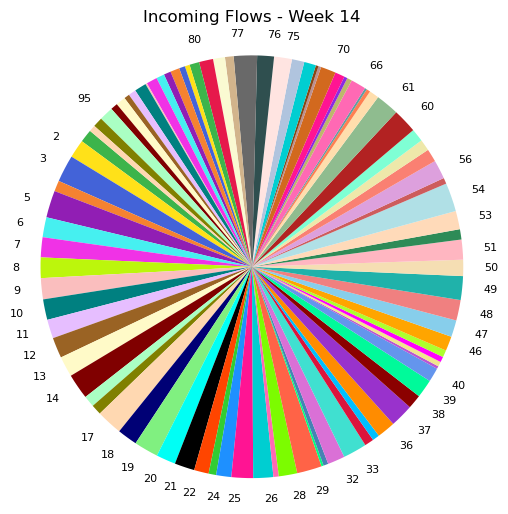

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week14_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week14_outgoing.png


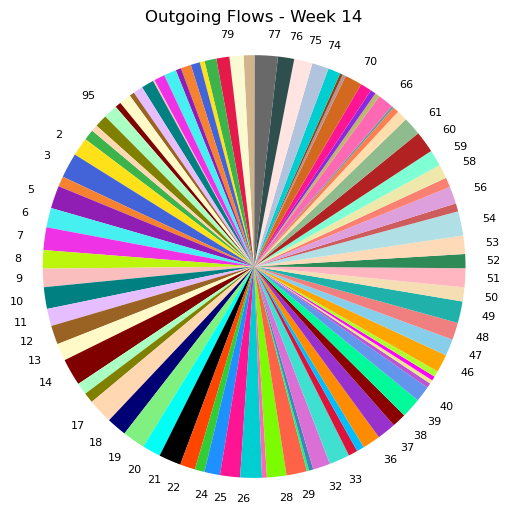


--- Incoming and Outgoing Flow Counts for Week 23 ---
Cluster 1: Incoming = 5, Outgoing = 5
Cluster 2: Incoming = 18, Outgoing = 23
Cluster 3: Incoming = 29, Outgoing = 24
Cluster 4: Incoming = 11, Outgoing = 9
Cluster 5: Incoming = 31, Outgoing = 30
Cluster 6: Incoming = 23, Outgoing = 22
Cluster 7: Incoming = 22, Outgoing = 23
Cluster 8: Incoming = 19, Outgoing = 17
Cluster 9: Incoming = 16, Outgoing = 17
Cluster 10: Incoming = 23, Outgoing = 26
Cluster 11: Incoming = 13, Outgoing = 16
Cluster 12: Incoming = 24, Outgoing = 19
Cluster 13: Incoming = 17, Outgoing = 20
Cluster 14: Incoming = 35, Outgoing = 33
Cluster 15: Incoming = 13, Outgoing = 12
Cluster 16: Incoming = 9, Outgoing = 9
Cluster 17: Incoming = 36, Outgoing = 38
Cluster 18: Incoming = 24, Outgoing = 27
Cluster 19: Incoming = 35, Outgoing = 30
Cluster 20: Incoming = 30, Outgoing = 30
Cluster 21: Incoming = 28, Outgoing = 24
Cluster 22: Incoming = 10, Outgoing = 12
Cluster 23: Incoming = 13, Outgoing = 17
Cluster 24: Inco

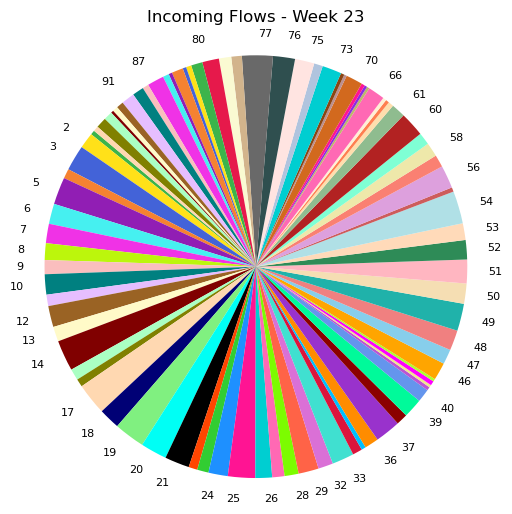

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week23_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week23_outgoing.png


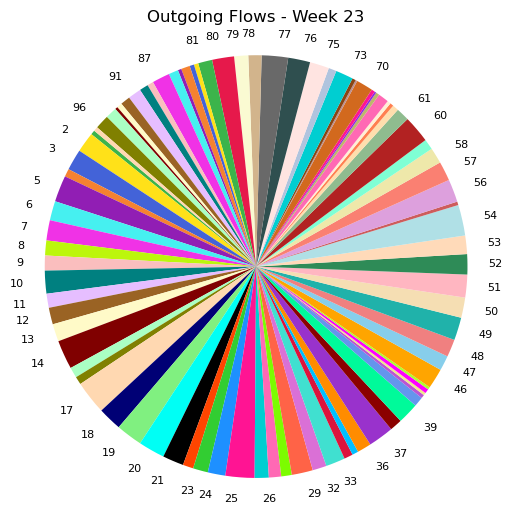


--- Incoming and Outgoing Flow Counts for Week All Weeks ---
Cluster 1: Incoming = 50, Outgoing = 48
Cluster 2: Incoming = 50, Outgoing = 48
Cluster 3: Incoming = 60, Outgoing = 55
Cluster 4: Incoming = 42, Outgoing = 40
Cluster 5: Incoming = 56, Outgoing = 49
Cluster 6: Incoming = 56, Outgoing = 51
Cluster 7: Incoming = 57, Outgoing = 55
Cluster 8: Incoming = 51, Outgoing = 44
Cluster 9: Incoming = 54, Outgoing = 48
Cluster 10: Incoming = 59, Outgoing = 50
Cluster 11: Incoming = 55, Outgoing = 49
Cluster 12: Incoming = 56, Outgoing = 50
Cluster 13: Incoming = 56, Outgoing = 48
Cluster 14: Incoming = 58, Outgoing = 60
Cluster 15: Incoming = 39, Outgoing = 37
Cluster 16: Incoming = 31, Outgoing = 31
Cluster 17: Incoming = 54, Outgoing = 53
Cluster 18: Incoming = 47, Outgoing = 49
Cluster 19: Incoming = 52, Outgoing = 51
Cluster 20: Incoming = 48, Outgoing = 44
Cluster 21: Incoming = 45, Outgoing = 47
Cluster 22: Incoming = 39, Outgoing = 44
Cluster 23: Incoming = 27, Outgoing = 33
Clus

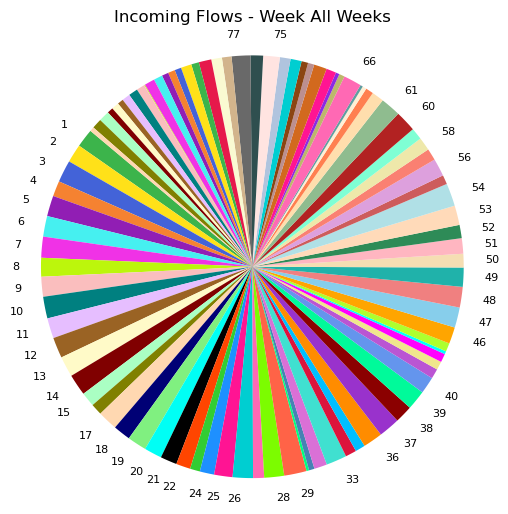

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_weekAll Weeks_outgoing.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_weekAll Weeks_outgoing.png


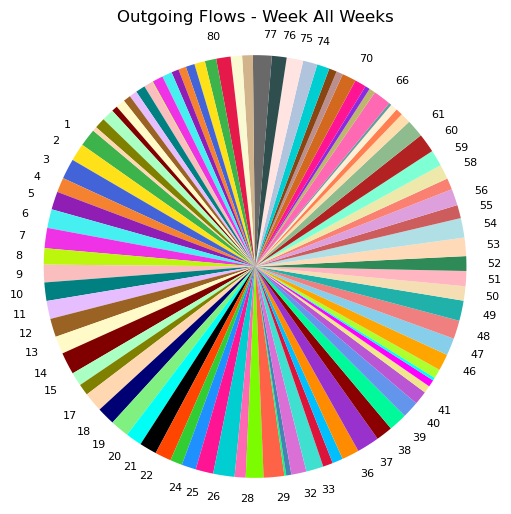

In [ ]:
for week_number in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_arena_sankey_and_pies(
        arena_data,
        week_number,
        eps_dir=eps_dir,
        mouse_name=mouse_name
    )

create_arena_sankey_and_pies(all_data, "All Weeks", eps_dir=eps_dir, mouse_name=mouse_name)

In [8]:
custom_colors = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32"
]

group_list = sorted(grouped_clusters['Group'].dropna().unique())
color_map = {int(group): custom_colors[i % len(custom_colors)] for i, group in enumerate(group_list)}

def map_grouped_clusters(df):
    return df.merge(grouped_clusters[['Cluster', 'Group']], left_on='Cluster', right_on='Cluster', how='left')

def create_grouped_sankey_plot(data, week_number, save_path=None, mouse_name=''):
    data = map_grouped_clusters(data)
    data['Next_Group'] = data['Group'].shift(-1)
    data = data.dropna(subset=['Group', 'Next_Group'])

    data['Group'] = data['Group'].astype(int)
    data['Next_Group'] = data['Next_Group'].astype(int)

    unique_groups = sorted(set(data['Group']).union(set(data['Next_Group'])))
    group_labels = [f"Group {g}" for g in unique_groups]
    label_indices = {f"Group {g}": i for i, g in enumerate(unique_groups)}
    n = len(unique_groups)

    transition_counts = data.groupby(['Group', 'Next_Group']).size().unstack(fill_value=0)
    transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

    source, target, values, colors = [], [], [], []

    for src in transition_probs.index:
        for tgt in transition_probs.columns:
            prob = transition_probs.at[src, tgt]
            if prob > 0:
                src_label = f"Group {src}"
                tgt_label = f"Group {tgt}"
                source.append(label_indices[src_label])
                target.append(label_indices[tgt_label] + n)
                values.append(prob)
                colors.append(color_map[src])

    scale = 0.6 
    offset = (1 - scale) / 2 
    y_values = [offset + scale * (i / (n - 1)) for i in range(n)] if n > 1 else [0.5]
    y_positions = y_values * 2
    x_positions = [0.1] * n + [0.9] * n

    fig = go.Figure(go.Sankey(
        node=dict(
            pad=20,
            thickness=25,
            line=dict(color="black", width=0.5),
            label=group_labels * 2,
            color="lightgray",
            x=x_positions,
            y=y_positions
        ),
        link=dict(
            source=source,
            target=target,
            value=values,
            color=colors
        )
    ))

    fig.update_layout(
        title_text=f"Grouped Cluster Transitions in {week_number}",
        font_size=12,
        height=1000,
        width=1000,
        margin=dict(l=10, r=100, t=50, b=50) 
    )

    if save_path is not None:
        eps_dir = save_path
        os.makedirs(eps_dir, exist_ok=True)
        base_filename = f"sankey_{mouse_name}_week{week_number}"

        svg_path = os.path.join(eps_dir, base_filename + ".svg")
        fig.write_image(svg_path)
        print(f"SVG saved to: {svg_path}")

        parent_dir = os.path.dirname(eps_dir)
        png_dir = os.path.join(parent_dir, "png")
        os.makedirs(png_dir, exist_ok=True)

        png_path = os.path.join(png_dir, base_filename + ".png")
        fig.write_image(png_path)
        print(f"PNG saved to: {png_path}")

    fig.show()

In [9]:
for arena in all_data['Week_Number'].dropna().unique():
    create_grouped_sankey_plot(
        all_data[all_data['Week_Number'] == arena],
        arena,
        save_path=eps_dir,
        mouse_name=mouse_name
    )

create_grouped_sankey_plot(
    all_data,
    "All_Weeks",
    save_path=eps_dir,
    mouse_name=mouse_name
)

SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_week8.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_week8.png


SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_week10.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_week10.png


SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_week12.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_week12.png


SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_week14.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_week14.png


SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_week23.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_week23.png


SVG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\sankey_2mp_weekAll_Weeks.svg
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\sankey_2mp_weekAll_Weeks.png


In [ ]:
cluster_to_group = dict(zip(grouped_clusters['Cluster'], grouped_clusters['Group']))
all_data['Group'] = all_data['Cluster'].map(cluster_to_group)

custom_colors = [
    "#32cd32", "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", "#911eb4", "#46f0f0", "#f032e6",
    "#bcf60c", "#fabebe", "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000", "#aaffc3",
    "#808000", "#ffd8b1", "#000075", "#80F080", "#00FFF5", "#000000", "#ff4500", "#32cd32",
]

def create_group_pie_flows(data, arena_name, eps_dir="", mouse_name=""):
    data = data.copy()
    data['Next_Group'] = data['Group'].shift(-1)
    data = data.dropna(subset=['Group', 'Next_Group'])

    data['Group'] = data['Group'].astype(int)
    data['Next_Group'] = data['Next_Group'].astype(int)

    all_groups = sorted(set(data['Group']).union(set(data['Next_Group'])))
    outgoing_counts = {f"Group {i}": 0 for i in all_groups}
    incoming_counts = {f"Group {i}": 0 for i in all_groups}

    for _, row in data.iterrows():
        src = f"Group {int(row['Group'])}"
        tgt = f"Group {int(row['Next_Group'])}"
        outgoing_counts[src] += 1
        incoming_counts[tgt] += 1


    print(f"--- Group Flow Counts for {arena_name} ---")
    for g in all_groups:
        gname = f"Group {g}"
        print(f"{gname}: Incoming = {incoming_counts[gname]}, Outgoing = {outgoing_counts[gname]}")

    def plot_pie_chart(counts, title, save_path=None):
        labels = list(counts.keys())
        sizes = list(counts.values())
        pie_colors = [custom_colors[int(label.split()[-1]) % len(custom_colors)] for label in labels]
        plt.figure(figsize=(6, 6))
        plt.pie(
            sizes,
            labels=[label.replace("Group ", "") for label in labels],
            colors=pie_colors,
            startangle=140,
            textprops={'fontsize': 8}
        )
        plt.title(title, pad=10)
        plt.axis('equal')

        if save_path is not None:
            eps_dir = os.path.dirname(save_path)
            if eps_dir:
                os.makedirs(eps_dir, exist_ok=True)

            base_filename = os.path.splitext(os.path.basename(save_path))[0]
            eps_path = os.path.join(eps_dir, base_filename + ".eps")
            plt.savefig(eps_path, format="eps", bbox_inches="tight")
            print(f"EPS saved to: {eps_path}")

            parent_dir = os.path.dirname(eps_dir)
            png_dir = os.path.join(parent_dir, "png")
            os.makedirs(png_dir, exist_ok=True)
            png_path = os.path.join(png_dir, base_filename + ".png")
            plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")
            print(f"PNG saved to: {png_path}")

        plt.show()

    incoming_chart = {k: v for k, v in incoming_counts.items() if v > 0}
    outgoing_chart = {k: v for k, v in outgoing_counts.items() if v > 0}

    incoming_path = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_incoming_grouped.eps"
    )
    outgoing_path = os.path.join(
        eps_dir,
        f"{mouse_name}_week{week_number}_outgoing_grouped.eps"
    )

    plot_pie_chart(incoming_chart, f"Incoming Group Flows - {arena_name}", save_path=incoming_path)
    plot_pie_chart(outgoing_chart, f"Outgoing Group Flows - {arena_name}", save_path=outgoing_path)


--- Group Flow Counts for 8 ---
Group 1: Incoming = 12720, Outgoing = 12720
Group 2: Incoming = 127, Outgoing = 127
Group 3: Incoming = 201, Outgoing = 201
Group 4: Incoming = 681, Outgoing = 681
Group 5: Incoming = 275, Outgoing = 275
Group 6: Incoming = 4214, Outgoing = 4214
Group 7: Incoming = 149, Outgoing = 149
Group 9: Incoming = 2890, Outgoing = 2890
Group 10: Incoming = 272, Outgoing = 272
Group 11: Incoming = 188, Outgoing = 188
Group 12: Incoming = 1365, Outgoing = 1365
Group 13: Incoming = 1267, Outgoing = 1267
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week8_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week8_incoming_grouped.png


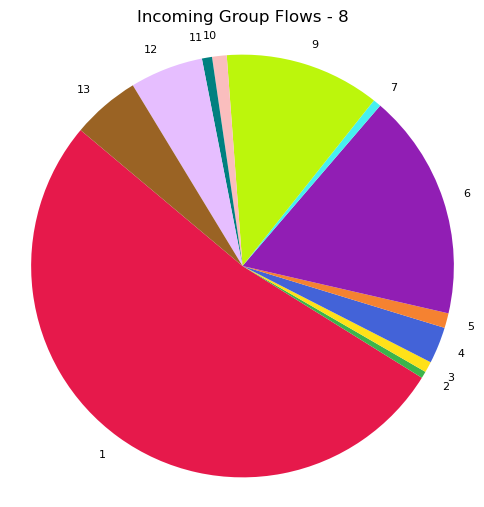

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week8_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week8_outgoing_grouped.png


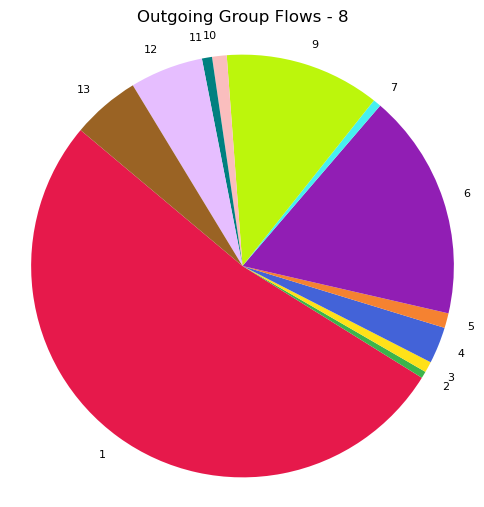

--- Group Flow Counts for 10 ---
Group 1: Incoming = 8541, Outgoing = 8541
Group 2: Incoming = 311, Outgoing = 311
Group 3: Incoming = 105, Outgoing = 105
Group 4: Incoming = 917, Outgoing = 917
Group 5: Incoming = 4096, Outgoing = 4096
Group 6: Incoming = 5958, Outgoing = 5958
Group 7: Incoming = 63, Outgoing = 63
Group 8: Incoming = 23, Outgoing = 23
Group 9: Incoming = 1938, Outgoing = 1938
Group 10: Incoming = 733, Outgoing = 733
Group 11: Incoming = 157, Outgoing = 157
Group 12: Incoming = 1720, Outgoing = 1720
Group 13: Incoming = 278, Outgoing = 278
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week10_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week10_incoming_grouped.png


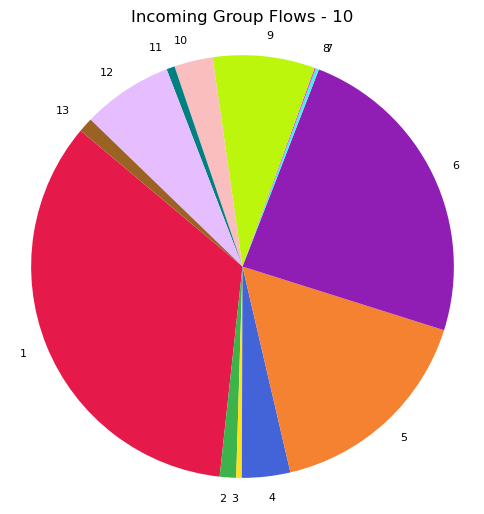

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week10_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week10_outgoing_grouped.png


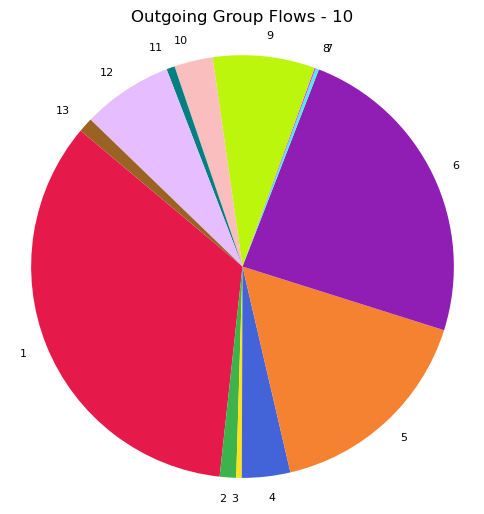

--- Group Flow Counts for 12 ---
Group 1: Incoming = 6962, Outgoing = 6962
Group 2: Incoming = 175, Outgoing = 175
Group 3: Incoming = 525, Outgoing = 525
Group 4: Incoming = 260, Outgoing = 260
Group 5: Incoming = 2998, Outgoing = 2998
Group 6: Incoming = 5758, Outgoing = 5758
Group 7: Incoming = 12, Outgoing = 12
Group 9: Incoming = 988, Outgoing = 988
Group 10: Incoming = 1849, Outgoing = 1849
Group 11: Incoming = 331, Outgoing = 331
Group 12: Incoming = 3983, Outgoing = 3983
Group 13: Incoming = 3, Outgoing = 3
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week12_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week12_incoming_grouped.png


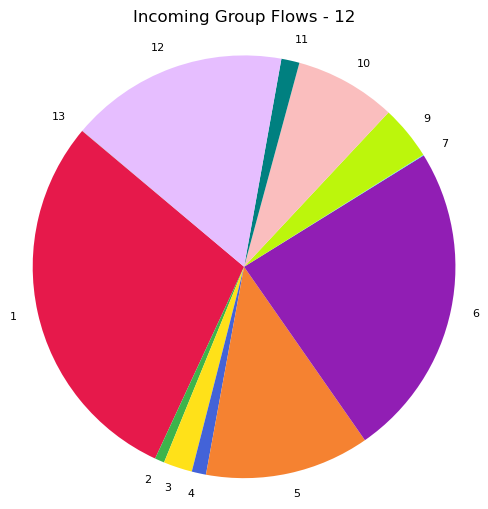

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week12_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week12_outgoing_grouped.png


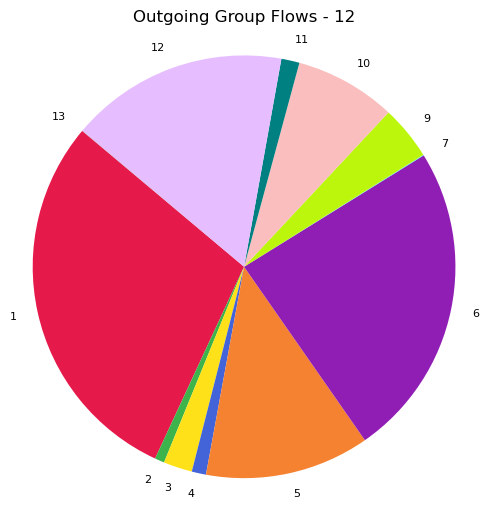

--- Group Flow Counts for 14 ---
Group 1: Incoming = 5295, Outgoing = 5295
Group 2: Incoming = 405, Outgoing = 405
Group 3: Incoming = 301, Outgoing = 301
Group 4: Incoming = 475, Outgoing = 475
Group 5: Incoming = 7059, Outgoing = 7059
Group 6: Incoming = 3624, Outgoing = 3624
Group 7: Incoming = 23, Outgoing = 23
Group 9: Incoming = 694, Outgoing = 694
Group 10: Incoming = 1989, Outgoing = 1989
Group 11: Incoming = 252, Outgoing = 252
Group 12: Incoming = 3811, Outgoing = 3811
Group 13: Incoming = 55, Outgoing = 55
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week14_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week14_incoming_grouped.png


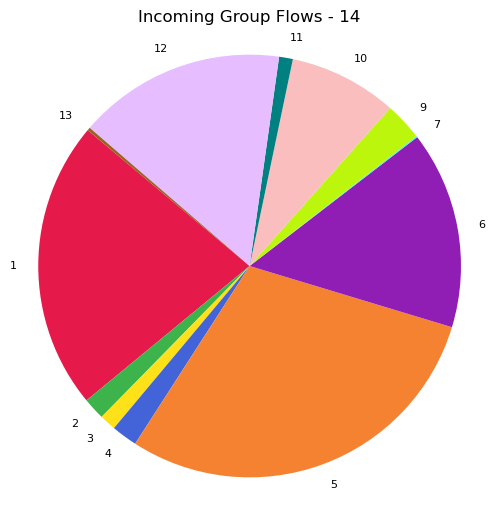

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week14_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week14_outgoing_grouped.png


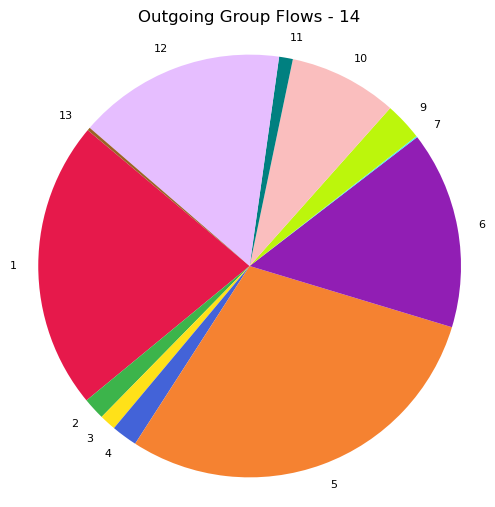

--- Group Flow Counts for 23 ---
Group 1: Incoming = 1840, Outgoing = 1840
Group 2: Incoming = 540, Outgoing = 540
Group 3: Incoming = 13, Outgoing = 13
Group 4: Incoming = 357, Outgoing = 358
Group 5: Incoming = 17409, Outgoing = 17409
Group 6: Incoming = 683, Outgoing = 683
Group 7: Incoming = 3, Outgoing = 3
Group 9: Incoming = 164, Outgoing = 164
Group 10: Incoming = 1102, Outgoing = 1101
Group 11: Incoming = 13, Outgoing = 13
Group 12: Incoming = 1812, Outgoing = 1812
Group 13: Incoming = 7, Outgoing = 7
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week23_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week23_incoming_grouped.png


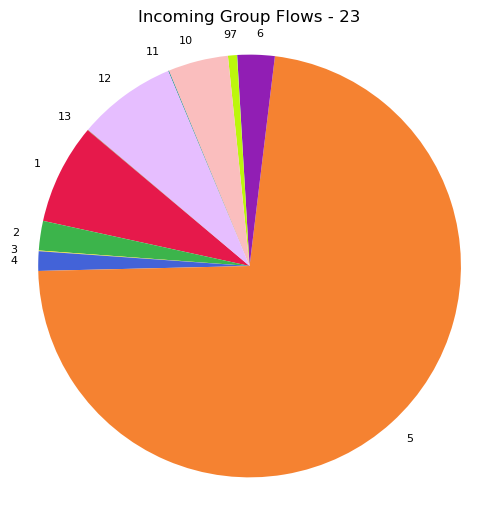

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week23_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week23_outgoing_grouped.png


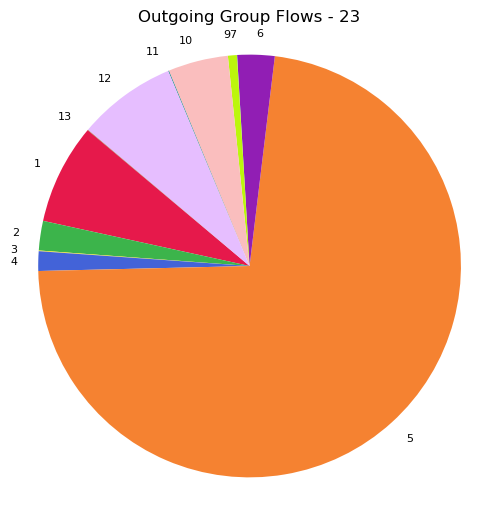

--- Group Flow Counts for All Weeks ---
Group 1: Incoming = 35361, Outgoing = 35362
Group 2: Incoming = 1558, Outgoing = 1558
Group 3: Incoming = 1145, Outgoing = 1145
Group 4: Incoming = 2691, Outgoing = 2691
Group 5: Incoming = 31837, Outgoing = 31837
Group 6: Incoming = 20237, Outgoing = 20237
Group 7: Incoming = 250, Outgoing = 250
Group 8: Incoming = 23, Outgoing = 23
Group 9: Incoming = 6674, Outgoing = 6674
Group 10: Incoming = 5945, Outgoing = 5944
Group 11: Incoming = 941, Outgoing = 941
Group 12: Incoming = 12691, Outgoing = 12691
Group 13: Incoming = 1610, Outgoing = 1610
EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week23_incoming_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week23_incoming_grouped.png


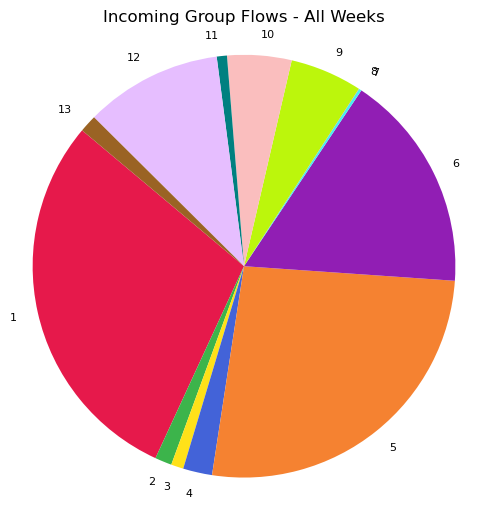

EPS saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\eps\2mp_week23_outgoing_grouped.eps
PNG saved to: D:\AccelClusterVisualizations\AccelCluster-Visualizations\Graphs\png\2mp_week23_outgoing_grouped.png


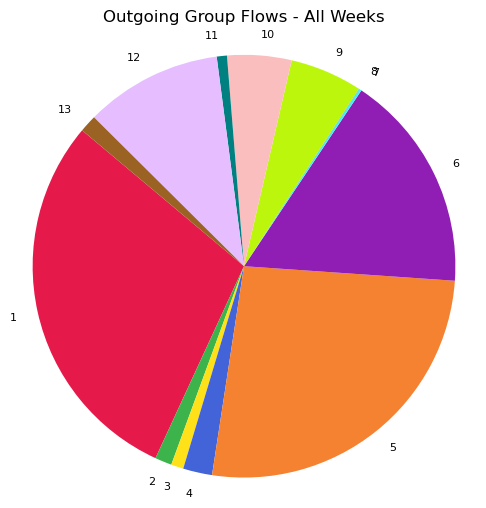

In [11]:
for week_number in week_numbers:
    arena_data = all_data[all_data['Week_Number'] == week_number]
    create_group_pie_flows(
        arena_data,
        week_number,
        eps_dir=eps_dir,
        mouse_name=mouse_name
    )

create_group_pie_flows(all_data, "All Weeks", eps_dir, mouse_name)